In [1]:
import pandas as pd
import numpy as np
import sys
import os
import re
import matplotlib.pyplot as plt

In [2]:
# conversion on erisone seems to be unstable. submitted all files twice. find files that show a larger filesize in second run than in the first run.

In [47]:
run1 = '//eris1fs2/CDAC/bedmaster_data/batching/ICUSleep_2/'
run1_part2 = '//eris1fs2/CDAC/bedmaster_data/batching/wg984_20191129_163322/'
run2 = '//eris1fs2/CDAC/bedmaster_data/batching/ICUSleep_3/'
run1_files = [x for x in os.listdir(run1) if '_v4.mat' in x] # +  [x for x in os.listdir(run1_part2) if '_v4.mat' in x]
run1_part2_files = [x for x in os.listdir(run1_part2) if '_v4.mat' in x]
run2_files = [x for x in os.listdir(run2) if '_v4.mat' in x]

run_small = '//eris1fs2/CDAC/bedmaster_data/batching/wg984_20191218_200148/'
run_small_files = [x for x in os.listdir(run_small) if '_v4.mat' in x]

In [4]:
files_only_run1 = list(set(run1_files) - set(run2_files))
print(files_only_run1)
[os.stat(os.path.join(run1, x)).st_size/1000000 for x in files_only_run1]

['BLK07_756-1564519196_0_v4.mat', 'BLK07_758-1539133548_1_v4.mat', 'BLK07_758-1552397514_0_v4.mat', 'BLK07_758-1539133548_0_v4.mat']


[472.395256, 333.365316, 501.500151, 461.534146]

In [5]:
set(run2_files) - set(run1_files);

In [6]:
files_both_runs = list(set(set(run1_files)|set(run1_part2_files)).intersection(set(run2_files)))
files_both_runs.sort()

In [7]:
filebases = np.unique([re.sub('_\d+_v4.mat','', x) for x in files_both_runs])

In [12]:
same_size = []
different_size = []
difference = []
larger_for_run1 = []
larger_for_run2 = []

for filebase in filebases:
    
    file1 = np.array([os.stat(os.path.join(run1, x)).st_size for x in files_both_runs if filebase in x]).astype('int64').sum()
    file2 = np.array([os.stat(os.path.join(run2, x)).st_size for x in files_both_runs if filebase in x]).astype('int64').sum()
                   
    if file1 == file2:
        same_size.append(filebase)
    else:
        different_size.append(filebase)
        difference.append(np.abs(file1-file2)/1000000)
        
        if file2>file1:
            larger_for_run2.append(filebase)
        else:
            larger_for_run1.append(filebase)
        
#         print(filebase)
#         print(int(file1/1000000))
#         print(int(file2/1000000))
#         print('\n')
        

FileNotFoundError: [WinError 2] The system cannot find the file specified: '//eris1fs2/CDAC/bedmaster_data/batching/ICUSleep_2/BIG9_936-1571633766_0_v4.mat'

In [171]:
pd.DataFrame(larger_for_run2, columns=['fileID']).to_csv('fileIDs_larger_for_run2_2.csv',index=False)

In [172]:
len(larger_for_run2)

24

In [173]:
larger_for_run2

['BLK07_770-1572939539',
 'BLK12_1252-1574537100',
 'BLK12_1284-1571648352',
 'BLK12_1286-1569826131',
 'BLK12_1288-1572039275',
 'ELL04_404-1571677212',
 'ELL04_406-1554232479',
 'ELL04_406-1573457523',
 'ELL04_414-1573355138',
 'ELL04_414-1574264837',
 'ELL04_418-1570824254',
 'ELL04_418-1572042464',
 'ELL04_418-1572468149',
 'ELL04_432-1571007865',
 'ELL09_924-1567536471',
 'ELL09_924-1573934681',
 'LUN06_640-1569708626',
 'LUN06_640-1573610005',
 'LUN07_774-1574655984',
 'LUN10_1012-1573002368',
 'LUN10_1012-1573508378',
 'LUN10_1022-1569371179',
 'LUN10_1022-1570722751',
 'LUN10_1026-1570202354']

In [155]:
print('same size:')
print(len(same_size))
print('different size:')
print(len(different_size))

same size:
42
different size:
47


Text(0, 0.5, 'count (#of fileIDs)')

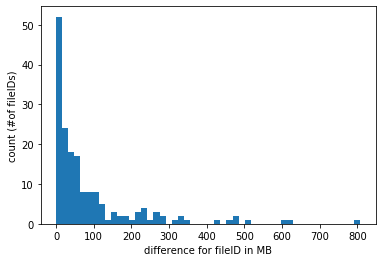

In [120]:
plt.hist([x for x in difference], bins=50)
plt.xlabel('difference for fileID in MB')
plt.ylabel('count (#of fileIDs)')

In [121]:
# dif of STP filesize and .mat

In [136]:
stp_filesizes = []
mat_filesizes = []
larger_stp_file = []
for filebase in filebases:
    
    stp_filesize = os.stat(os.path.join(run1, filebase+'.stp')).st_size/1000000
    files_mat1 = np.array([os.stat(os.path.join(run1, x)).st_size for x in files_both_runs if filebase in x]).astype('int64').sum()
    files_mat2 = np.array([os.stat(os.path.join(run2, x)).st_size for x in files_both_runs if filebase in x]).astype('int64').sum()
    files_mat = np.max([files_mat1, files_mat2])/1000000
    
    stp_filesizes.append(stp_filesize)
    mat_filesizes.append(files_mat)

    if stp_filesize > files_mat:
        larger_stp_file.append(filebase)
        print(filebase)
        print(int(files_mat))
        print(int(stp_filesize))

BIG13_1326-1558386657
3260
3726
BIG13_1344-1546826010
2668
3088
BIG13_1352-1558721260
1191
3954
BIG13_1354-1561066693
2496
2579
BLK07_756-1564519196
260
720
BLK07_760-1549074610
132
1334
BLK07_766-1549067030
11
694
BLK07_778-1565458971
1146
1165
BLK07_788-1540676544
41
172
BLK07_790-1548910095
593
1147
BLK07_790-1549689022
202
323
BLK08_876-1543880125
1745
3104
BLK08_880-1568678354
444
530
BLK12_1254-1539466836
18
174
BLK12_1254-1547520918
338
391
BLK12_1256-1550775179
552
1236
BLK12_1258-1546474180
1240
4847
BLK12_1260-1533560479
1050
1150
BLK12_1260-1559503670
941
970
BLK12_1266-1529051991
158
1081
BLK12_1276-1541194607
11
812
BLK12_1280-1547913492
2947
3379
BLK12_1280-1551438131
104
472
BLK12_1284-1535222774
299
947
BLK12_1284-1536287410
7
238
BLK12_1284-1536542945
11
143
BLK12_1284-1540337896
257
445
BLK12_1284-1541906692
2036
2418
ELL04_402-1549599295
523
1388
ELL04_410-1554296252
6
551
ELL04_424-1537837052
516
3528
ELL04_430-1554222823
93
114
ELL04_432-1555456610
229
305
ELL04_43

In [132]:
stp_filesizes = np.array(stp_filesizes)
mat_filesizes = np.array(mat_filesizes)
print('larger .mat files')
print(((stp_filesizes - mat_filesizes)<0).sum())
print('larger .STP files')
print(((stp_filesizes - mat_filesizes)>0).sum())


larger .mat files
370
larger .STP files
41


In [9]:
pd.DataFrame(larger_stp_file, columns = ['fileID']).to_csv('C:/Users/wg984/Wolfgang/repos/ICU-Sleep/data/fileIDs_larger_STP_than_mat_after_LargeBundleSize_conversion.csv', index=False)

NameError: name 'larger_stp_file' is not defined

In [10]:
fileIDs_converted_path = '//mad3/MGH-NEURO-CDAC/Projects/ICU_SLEEP_STUDY/data/data_analysis/BMR_fileID/'
fileIDs_converted = os.listdir(fileIDs_converted_path)
fileIDs_converted = [x.split('.h5')[0] for x in fileIDs_converted]

In [49]:
filebases_run1 = np.unique([re.sub('_\d+_v4.mat','', x) for x in run1_files])
filebases_run1_2 = np.unique([re.sub('_\d+_v4.mat','', x) for x in run1_part2_files])
filebases_run2 = np.unique([re.sub('_\d+_v4.mat','', x) for x in run2_files])
filebases_run_small = np.unique([re.sub('_\d+_v4.mat','', x) for x in run_small_files])

In [12]:
filebases_run1.shape

(413,)

In [13]:
fileIDs_not_converted1 = list(filebases_run1[np.logical_not(np.in1d(filebases_run1, fileIDs_converted))])

In [14]:
fileIDs_not_converted2 = list(filebases_run2[np.logical_not(np.in1d(filebases_run2, fileIDs_converted))])

In [15]:
fileIDs_not_converted = fileIDs_not_converted1 + fileIDs_not_converted2

In [16]:
fileIDs_not_converted = list(np.unique(fileIDs_not_converted))
len(fileIDs_not_converted)

71

In [59]:
# BMR fileID
bmr_fileid_dir = '//mad3/MGH-NEURO-CDAC/Projects/ICU_SLEEP_STUDY/data/data_analysis/BMR_fileID'
bmr_fileid_files = os.listdir(bmr_fileid_dir)

LogDir = '//mad3/MGH-NEURO-CDAC/Projects/ICU_SLEEP_STUDY/data/data_analysis/Study/'
filep=LogDir+'ConversionStatus.csv'
filep=LogDir+'ICUSleep_DataTable_ICUonly.csv'
ICUSleep_DataTable = pd.read_csv(filep)

In [60]:
file_ids_all = []
for x in ICUSleep_DataTable.BMFileID.dropna().values:
    file_ids_all += x.split(',')
file_ids_all = pd.unique(file_ids_all)

In [69]:
# file_ids_all = np.unique(ConversionStatus.fileID)
fileIDs_available = [x.split('.h5')[0] for x in bmr_fileid_files if not 'run' in x]
fileIDs_not_converted = list(set(file_ids_all) - set(fileIDs_available))
len(fileIDs_not_converted)

12

In [73]:
folder = []
folders = [run1, run1_part2, run2, run_small]


for filebase in fileIDs_not_converted:
    file1 = 0
    file1_2 = 0
    file2 = 0
    file_small = 0
    
    if filebase in filebases_run1:
        file1 = np.array([os.stat(os.path.join(run1, x)).st_size for x in run1_files if filebase in x]).astype('int64').sum()
    if filebase in filebases_run1_2:
        file1_2 = np.array([os.stat(os.path.join(run1_part2, x)).st_size for x in run1_part2_files if filebase in x]).astype('int64').sum()
    if filebase in filebases_run2:
        file2 = np.array([os.stat(os.path.join(run2, x)).st_size for x in run2_files if filebase in x]).astype('int64').sum()
    if filebase in filebases_run_small:
        file_small =  np.array([os.stat(os.path.join(run_small, x)).st_size for x in run_small_files if filebase in x]).astype('int64').sum()
    
    print( np.max([file1, file1_2, file2, file_small])/1000000 )
    
#     folder.append(folders[np.argmax([file1, file1_2, file2, file_small*0.8])])

0.22136
0.014272
0.149336
0.0
529.92927
0.123704
414.2921
0.114736
0.81109
0.189136
0.143232
0.033168


In [63]:
len(folder)

12

In [64]:
len(fileIDs_not_converted)

12

In [65]:
fileIDs_not_converted = pd.DataFrame(np.array([fileIDs_not_converted, folder]).transpose(), columns = ['fileID', 'folder'])

In [66]:
fileIDs_not_converted.to_csv('C:/Users/wg984/Wolfgang/repos/ICU-Sleep/data/fileIDs_not_converted_20_12.csv', index=False)

In [67]:
run1_files.index('BIG9_936-1571633766_0_v4.mat')

ValueError: 'BIG9_936-1571633766_0_v4.mat' is not in list

1

In [22]:
file1

0

In [23]:
file1_2

317274104

In [24]:
file2

317274104

In [66]:
filebase in run1_files

False

In [39]:
filedir = '//eris1fs2/CDAC/bedmaster_data/batching/wg984_20191218_200148'
files = [x for x in os.listdir(filedir) if '_v4.mat' in x] # +  [x for x in os.listdir(run1_part2) if '_v4.mat' in x]
filebases = np.unique([re.sub('_\d+_v4.mat','', x) for x in files])
pd.DataFrame(filebases, columns = ['fileID']).to_csv('C:/Users/wg984/Wolfgang/repos/ICU-Sleep/data/smallBundleSizeConversion.csv', index=False)

In [40]:
filebases.shape

(41,)